# Player Similarity — EDA
EA Sports FC 26 attribute data (top-5 leagues). 3,204 players × 44 features.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
pd.set_option('display.max_columns', None)

df = pd.read_parquet('data/fifa_players.parquet')
print(df.shape)
df.head()

(3204, 58)


,player_id,short_name,long_name,player_positions,club_name,league_name,nationality_name,age,height_cm,weight_kg,preferred_foot,overall,potential,value_eur,pace,shooting,passing,dribbling,defending,physic,skill_moves,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,weak_foot,international_reputation
0,252371,J. Bellingham,Jude Victor William Bellingham,"CAM, CM",Real Madrid,La Liga,England,22,186,75,Right,90,94,174500000,80.0,86.0,83.0,90.0,78.0,85.0,4,66,88,75,90,77,91,73,68,89,91,81,80,83,91,83,86,85,94,80,87,85,82,91,90,74,90,77,79,77,14,11,10,5,8,0.0,4,5
1,239053,F. Valverde,Federico Santiago Valverde Dipetta,"CM, CDM, RB",Real Madrid,La Liga,Uruguay,26,182,74,Right,89,90,120500000,88.0,84.0,84.0,84.0,83.0,85.0,3,78,80,63,88,78,84,76,69,88,88,84,92,77,89,68,91,82,93,82,91,81,86,86,86,59,84,82,87,86,6,10,6,15,8,0.0,4,4
2,212622,J. Kimmich,Joshua Walter Kimmich,"CDM, RB, CM",FC Bayern München,Bundesliga,Germany,30,177,75,Right,89,89,86000000,72.0,74.0,89.0,84.0,83.0,79.0,3,92,68,72,89,69,82,85,79,92,86,75,70,83,89,84,78,77,92,69,83,89,85,78,86,71,86,82,86,85,8,15,7,15,15,0.0,4,4
3,235212,A. Hakimi,Achraf Hakimi Mouhأشرف حكيمي,"RB, RM",Paris Saint-Germain,Ligue 1,Morocco,26,181,73,Right,89,90,111000000,92.0,79.0,82.0,83.0,82.0,79.0,4,85,80,71,86,74,82,78,80,73,85,89,95,81,90,78,82,84,95,72,77,77,85,84,78,68,84,82,85,79,10,8,14,6,8,0.0,4,4
4,224232,N. Barella,Nicolò Barella,CM,Inter,Serie A,Italy,28,175,68,Right,87,87,79500000,80.0,78.0,84.0,86.0,81.0,76.0,3,79,77,60,89,80,84,79,67,87,87,82,78,91,91,88,80,75,89,66,79,87,85,84,85,73,88,80,85,80,11,5,13,14,11,0.0,4,4


In [2]:
# Identity vs feature columns
id_cols = ['player_id','short_name','long_name','player_positions','club_name',
           'league_name','nationality_name','age','height_cm','weight_kg',
           'preferred_foot','overall','potential','value_eur']
feature_cols = [c for c in df.columns if c not in id_cols]
print(len(feature_cols), 'features')
df[feature_cols].describe().T

44 features


,count,mean,std,min,25%,50%,75%,max
pace,3204.0,62.137953,24.900947,0.0,60.00,69.0,77.0,97.0
shooting,3204.0,51.309613,23.338399,0.0,40.00,58.0,69.0,92.0
passing,3204.0,56.547441,22.714917,0.0,54.00,63.0,71.0,92.0
dribbling,3204.0,60.809301,23.944992,0.0,60.00,69.0,75.0,93.0
defending,3204.0,50.999688,24.963558,0.0,34.00,61.0,71.0,90.0
physic,3204.0,59.899501,23.672535,0.0,58.00,67.0,74.0,91.0
skill_moves,3204.0,2.557740,0.878920,1.0,2.00,3.0,3.0,5.0
attacking_crossing,3204.0,54.300562,20.021886,8.0,43.00,60.0,69.0,93.0
attacking_finishing,3204.0,50.958801,21.819031,4.0,35.00,57.0,68.0,94.0
attacking_heading_accuracy,3204.0,56.289326,19.411855,6.0,48.00,61.0,70.0,91.0


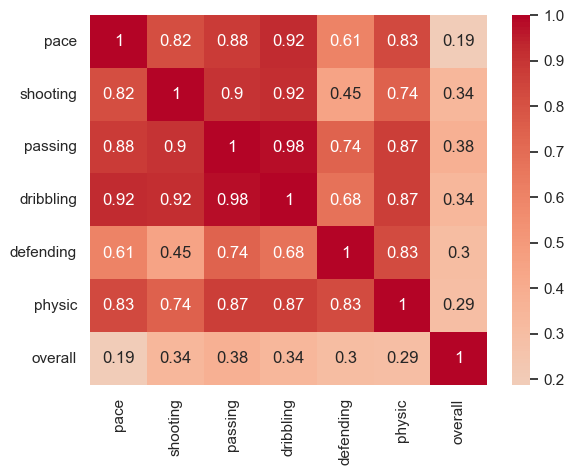

In [3]:
# Correlation heatmap of the headline attributes
headline = ['pace','shooting','passing','dribbling','defending','physic','overall']
sns.heatmap(df[headline].corr(), annot=True, cmap='coolwarm', center=0)
plt.show()

In [4]:
# Players per league
df['league_name'].value_counts()

league_name
Bundesliga        866
Serie A           687
Premier League    609
La Liga           554
Ligue 1           488
Name: count, dtype: int64

In [22]:
df.head(5)

,player_id,short_name,long_name,player_positions,club_name,league_name,nationality_name,age,height_cm,weight_kg,preferred_foot,overall,potential,value_eur,pace,shooting,passing,dribbling,defending,physic,skill_moves,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,weak_foot,international_reputation,primary_pos
0,252371,J. Bellingham,Jude Victor William Bellingham,"CAM, CM",Real Madrid,La Liga,England,22,186,75,Right,90,94,174500000,80.0,86.0,83.0,90.0,78.0,85.0,4,66,88,75,90,77,91,73,68,89,91,81,80,83,91,83,86,85,94,80,87,85,82,91,90,74,90,77,79,77,14,11,10,5,8,0.0,4,5,CAM
1,239053,F. Valverde,Federico Santiago Valverde Dipetta,"CM, CDM, RB",Real Madrid,La Liga,Uruguay,26,182,74,Right,89,90,120500000,88.0,84.0,84.0,84.0,83.0,85.0,3,78,80,63,88,78,84,76,69,88,88,84,92,77,89,68,91,82,93,82,91,81,86,86,86,59,84,82,87,86,6,10,6,15,8,0.0,4,4,CM
2,212622,J. Kimmich,Joshua Walter Kimmich,"CDM, RB, CM",FC Bayern München,Bundesliga,Germany,30,177,75,Right,89,89,86000000,72.0,74.0,89.0,84.0,83.0,79.0,3,92,68,72,89,69,82,85,79,92,86,75,70,83,89,84,78,77,92,69,83,89,85,78,86,71,86,82,86,85,8,15,7,15,15,0.0,4,4,CDM
3,235212,A. Hakimi,Achraf Hakimi Mouhأشرف حكيمي,"RB, RM",Paris Saint-Germain,Ligue 1,Morocco,26,181,73,Right,89,90,111000000,92.0,79.0,82.0,83.0,82.0,79.0,4,85,80,71,86,74,82,78,80,73,85,89,95,81,90,78,82,84,95,72,77,77,85,84,78,68,84,82,85,79,10,8,14,6,8,0.0,4,4,RB
4,224232,N. Barella,Nicolò Barella,CM,Inter,Serie A,Italy,28,175,68,Right,87,87,79500000,80.0,78.0,84.0,86.0,81.0,76.0,3,79,77,60,89,80,84,79,67,87,87,82,78,91,91,88,80,75,89,66,79,87,85,84,85,73,88,80,85,80,11,5,13,14,11,0.0,4,4,CM


In [28]:
df[df["club_name"] == "Paris Saint-Germain"]

,player_id,short_name,long_name,player_positions,club_name,league_name,nationality_name,age,height_cm,weight_kg,preferred_foot,overall,potential,value_eur,pace,shooting,passing,dribbling,defending,physic,skill_moves,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,weak_foot,international_reputation,primary_pos
3,235212,A. Hakimi,Achraf Hakimi Mouhأشرف حكيمي,"RB, RM",Paris Saint-Germain,Ligue 1,Morocco,26,181,73,Right,89,90,111000000,92.0,79.0,82.0,83.0,82.0,79.0,4,85,80,71,86,74,82,78,80,73,85,89,95,81,90,78,82,84,95,72,77,77,85,84,78,68,84,82,85,79,10,8,14,6,8,0.0,4,4,RB
18,255253,Vitinha,Vítor Machado Ferreira,"CM, CDM, CAM",Paris Saint-Germain,Ligue 1,Portugal,25,172,64,Right,89,91,128500000,72.0,80.0,86.0,90.0,75.0,70.0,4,78,80,52,90,62,91,81,69,89,88,75,69,91,88,89,77,66,87,59,84,77,85,81,90,88,88,74,79,69,12,13,8,5,5,0.0,3,4,CM
29,231443,O. Dembélé,Masour Ousmane Dembélé,"ST, RW, CAM",Paris Saint-Germain,Ligue 1,France,28,178,67,Left,90,90,122500000,91.0,88.0,83.0,93.0,50.0,69.0,5,80,90,74,89,79,94,85,68,78,94,93,89,94,91,81,91,84,76,69,85,58,45,95,84,80,88,49,49,39,6,6,14,10,13,0.0,5,5,ST
30,272834,João Neves,João Pedro Gonçalves Neves,"CM, CDM",Paris Saint-Germain,Ligue 1,Portugal,20,174,66,Right,85,90,79500000,74.0,71.0,80.0,84.0,82.0,83.0,3,67,69,72,86,75,83,74,53,86,86,77,71,84,83,86,78,83,92,78,68,84,84,77,84,60,85,83,83,80,8,7,5,13,13,0.0,4,3,CM
36,247635,K. Kvaratskhelia,Khvicha Kvaratskheliaხვიჩა კვარაცხელია,"LW, RW, LM",Paris Saint-Germain,Ligue 1,Georgia,24,183,70,Right,87,90,109000000,86.0,80.0,83.0,88.0,58.0,78.0,5,79,81,62,87,64,89,86,74,78,88,85,86,86,84,84,78,87,83,76,86,73,58,87,85,70,84,53,62,52,9,15,8,14,8,0.0,5,3,LW
57,252145,Nuno Mendes,Nuno Alexandre Tavares Mendes,"LB, LM",Paris Saint-Germain,Ligue 1,Portugal,23,180,70,Left,86,89,86000000,95.0,65.0,76.0,82.0,80.0,77.0,3,81,61,73,80,54,81,77,59,72,82,94,95,87,83,84,80,87,83,73,64,75,79,77,72,45,82,77,86,81,7,8,8,12,15,0.0,4,3,LB
115,226271,Fabián Ruiz,Fabián Ruiz Peña,"CM, CDM",Paris Saint-Germain,Ligue 1,Spain,29,189,70,Left,85,85,52500000,61.0,77.0,80.0,81.0,75.0,72.0,3,72,76,68,85,67,82,75,61,83,86,61,61,66,85,67,78,70,84,67,82,68,79,84,84,67,82,71,79,75,16,11,7,13,13,0.0,3,3,CM
122,271421,D. Doué,Désiré Doué,"RW, LW, CM, RM",Paris Saint-Germain,Ligue 1,France,20,181,79,Right,85,91,83500000,83.0,80.0,77.0,90.0,55.0,74.0,5,74,78,46,81,68,91,82,68,74,89,85,82,88,85,87,86,75,80,77,83,61,59,81,78,71,89,52,60,52,9,12,7,5,13,0.0,4,3,RW
148,270673,W. Zaïre-Emery,Warren Zaïre-Emery,"CM, CDM, CAM",Paris Saint-Germain,Ligue 1,France,19,178,68,Right,80,87,41000000,79.0,68.0,76.0,79.0,75.0,79.0,3,68,66,66,82,49,78,66,53,81,81,80,78,74,79,84,76,80,88,75,69,76,79,76,79,59,78,71,80,73,14,11,7,8,15,0.0,4,1,CM
264,207865,Marquinhos,Marcos Aoás Corrêa,CB,Paris Saint-Germain,Ligue 1,Brazil,31,183,75,Right,87,87,54500000,78.0,56.0,75.0,74.0,89.0,80.0,3,68,59,88,84,35,69,58,32,85,79,75,80,68,86,67,65,89,79,79,45,81,89,70,76,52,86,90,89,88,6,6,12,10,13,0.0,3,4,CB


In [9]:
from similarity import PlayerSimilarity

In [29]:
model = PlayerSimilarity() 

model.find_similar("O. Dembélé")

Most similar to O. Dembélé (ST, Paris Saint-Germain, overall 90):


,short_name,primary_pos,club_name,league_name,age,overall,value_eur,similarity
0,K. Mbappé,ST,Real Madrid,La Liga,26,91,173500000,97.1
1,J. Alvarez,ST,Atlético Madrid,La Liga,25,87,107000000,95.0
2,Vini Jr.,LW,Real Madrid,La Liga,24,89,141000000,94.6
3,Ferran Torres,LW,FC Barcelona,La Liga,25,83,48000000,94.2
4,Ayoze,ST,Villarreal CF,La Liga,31,83,30500000,94.1
5,K. Kvaratskhelia,LW,Paris Saint-Germain,Ligue 1,24,87,109000000,93.9
6,B. Barcola,LW,Paris Saint-Germain,Ligue 1,22,84,61500000,93.9
7,L. Martínez,ST,Inter,Serie A,27,88,99000000,93.7
8,Rodrygo,RW,Real Madrid,La Liga,24,85,81500000,93.6
9,C. Pulisic,RW,AC Milan,Serie A,26,84,46000000,93.6
